In [1]:
import torch
import numpy as np
import scipy
import time
import os
from scipy.ndimage import zoom

In [2]:
import sys
sys.path.append('/home/yonglihe/github/HolisticMRI/mrphy_ss/')
#import mobjs
from mobjs import Pulse, SpinCube

In [3]:
import matplotlib.pyplot as plt

In [4]:
import sys
sys.path.append('/home/yonglihe/github/my_utils')
from vis import SACshow, pulse2np, plot_seq, g2k, compare_pulses, errormap_cmp

Visualize the trajectory of a steady-state OVS tailored pulse in the excitation k space

(1570,) (1570,) (1570,)


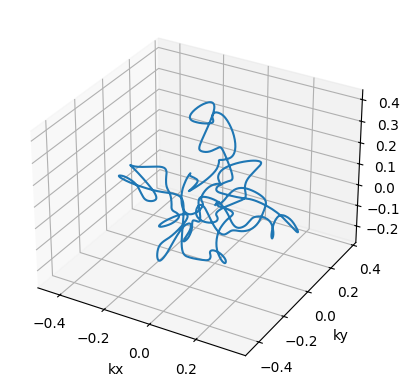

torch.Size([1570, 3])

In [5]:
pulse_npz=np.load('/home/yonglihe/github/ROI-GUIDE/data/pAD-EXT-guide-PHANTOM-TR80ms.npz')

gr0=torch.tensor(pulse_npz['gr']).squeeze(0)
traj0=g2k(gr0)
traj0.shape

Save the trajectory (ndim by nTime) to an .npz file

In [6]:
np.save('./init_traj_OVS.npy',traj0.permute(1,0).numpy())

In [7]:
traj_ref=np.load('./init_traj_OVS.npy')
traj_ref.shape

(3, 1570)

Load the Bspline sampling trajectory model from BJORK frame work

In [8]:
sys.path.append('/home/yonglihe/github/HolisticMRI/training')
from models.networks import SamplingLayerBspline3D as Bspline

/home/yonglihe/miniconda3/envs/holisticMRI/lib/python3.11/site-packages/memcnn/models/revop.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd(cast_inputs=torch.float32)
/home/yonglihe/miniconda3/envs/holisticMRI/lib/python3.11/site-packages/memcnn/models/revop.py:73: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd


In [9]:
num_shots=1
nfe=gr0.shape[-1]

model=Bspline(num_shots,nfe,init_traj='./init_traj_OVS.npy',decim=4)

In [10]:
model.coeff.shape

torch.Size([3, 1, 392])

In [11]:
def view_coeff(model):
    coeff = model.coeff.detach().squeeze(1).cpu().numpy()  # Shape becomes (3, 392)

    # Plot each row
    for i, row in enumerate(coeff):
        plt.plot(row, label=f'Row {i}')

    # Add legend and show the plot
    plt.legend()
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.title('Plot of Each Row')
    plt.show()
    return

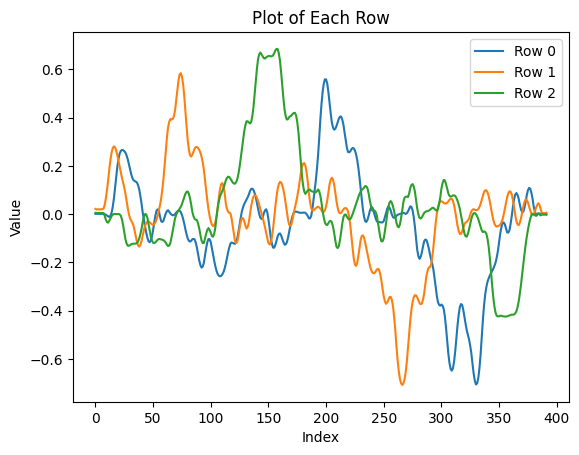

In [12]:
view_coeff(model)

Play around with the coefficients

In [13]:
with torch.no_grad():
    model.coeff[2,...]=0

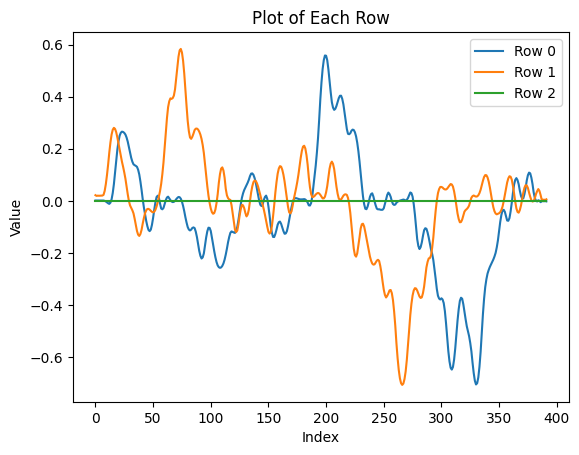

In [14]:
view_coeff(model)

In [15]:
model.B.shape

torch.Size([392, 1610])

In [16]:
traj,gr,sl=model(1)

(1569,) (1569,) (1569,)


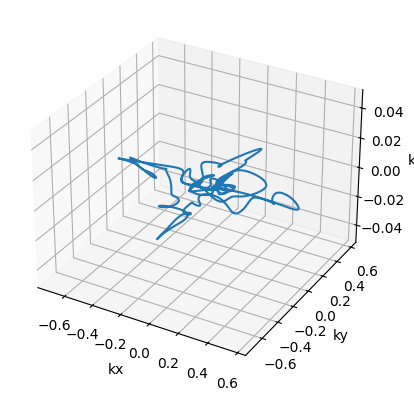

In [17]:
_=g2k(gr.detach().squeeze(1).cpu())

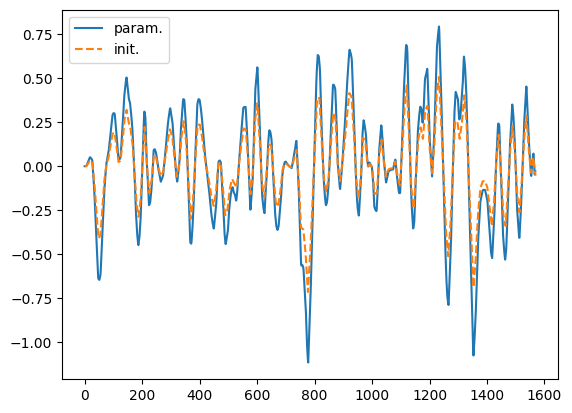

In [20]:
gr1=gr.squeeze(1).detach().cpu()

for i in [0]:
    plt.plot(gr1[i,:],label='param.')
    plt.plot(gr0[i,:],'--',label='init.')
plt.legend()
plt.show()

In [24]:
gr.shape

torch.Size([3, 1, 1569])

In [25]:
gr_tst=torch.nn.functional.pad(gr,(1,0),'constant',0)

In [27]:
gr_tst

tensor([[[ 0.0000e+00, -1.0092e-04, -1.9080e-04,  ..., -4.6819e-02,
          -3.9803e-02, -2.8922e-02]],

        [[ 0.0000e+00, -3.9766e-03, -7.0024e-03,  ...,  2.5066e-01,
           1.9489e-01,  1.3261e-01]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]]], device='cuda:0',
       grad_fn=<ConstantPadNdBackward0>)